In [168]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import os

In [169]:
class LSTM(nn.Module):
    def __init__(self,h=64,nf=14): 
        super().__init__()
        #input dim is 32,1,14
        self.wii = nn.Linear(nf,h,bias=True) # (14,64)
        self.wif = nn.Linear(nf,h,bias=True)
        self.wig = nn.Linear(nf,h,bias=True)
        self.wio = nn.Linear(nf,h,bias=True)
        
        self.whi = nn.Linear(h,h,bias=True) # (64,64)
        self.whf = nn.Linear(h,h,bias=True)
        self.whg = nn.Linear(h,h,bias=True)
        self.who = nn.Linear(h,h,bias=True)

        self.lin_layer = nn.Linear(64,14,bias =True)
        
    def forward(self,x,h,ct_e):#x is (32,10,14), h,ct (torch.zeros of dim(32,64))
        for i in range(0,10): 
            x_it = x[:,i,:] # x_it = (32,14)
            input_gate = torch.sigmoid(self.wii(x_it) + self.whi(h))
            filter_gate = torch.sigmoid(self.wif(x_it) + self.whf(h))
            output_gate = torch.sigmoid(self.wio(x_it) + self.who(h))
            g_t = torch.tanh(self.wig(x_it) + self.whg(h))
            ct_e = filter_gate * ct_e + input_gate * g_t
            h = output_gate * torch.tanh(ct_e)
        logits = self.lin_layer(h)
        return h,logits

    def con_pred(self,x,h,ct_e):
        x_it = x[:,0,:]
        for i in range(10):
            input_gate = torch.sigmoid(self.wii(x_it) + self.whi(h))
            filter_gate = torch.sigmoid(self.wif(x_it) + self.whf(h))
            output_gate = torch.sigmoid(self.wio(x_it) + self.who(h))
            g_t = torch.tanh(self.wig(x_it) + self.whg(h))
            ct_e = filter_gate * ct_e + input_gate * g_t
            h = output_gate * torch.tanh(ct_e)
            x_it  = self.lin_layer(h)
        return h,x_it

    def forecast(self, x, h, ct_e, future):
        seq_length = x.shape[1] # This is 10
        for i in range(seq_length):
            x_it = x[:, i, :]
            input_gate = torch.sigmoid(self.wii(x_it) + self.whi(h))
            filter_gate = torch.sigmoid(self.wif(x_it) + self.whf(h))
            output_gate = torch.sigmoid(self.wio(x_it) + self.who(h))
            g_t = torch.tanh(self.wig(x_it) + self.whg(h))
            ct_e = filter_gate * ct_e + input_gate * g_t
            h = output_gate * torch.tanh(ct_e)
            
        x_it = self.lin_layer(h)
        
        predictions = []
        
        for i in range(future):
            predictions.append(x_it)
            
            input_gate = torch.sigmoid(self.wii(x_it) + self.whi(h))
            filter_gate = torch.sigmoid(self.wif(x_it) + self.whf(h))
            output_gate = torch.sigmoid(self.wio(x_it) + self.who(h))
            g_t = torch.tanh(self.wig(x_it) + self.whg(h))
            ct_e = filter_gate * ct_e + input_gate * g_t
            h = output_gate * torch.tanh(ct_e)
            
            x_it = self.lin_layer(h)
            
        return torch.stack(predictions, dim=1)

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mnassrib/jena-climate")

print("Path to dataset files:", path)

/Users/admin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/admin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████| 13.2M/13.2M [00:05<00:00, 2.55MB/s]

Extracting files...


Path to dataset files: /Users/admin/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1


In [170]:
df = pd.read_csv('/Users/admin/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1/jena_climate_2009_2016.csv')

In [171]:
df_subset = df.iloc[:, 1:]
new_df = df_subset.groupby(np.arange(len(df_subset)) // 6).mean()
new_df = (new_df - new_df.mean()) / new_df.std()

In [172]:
model1 = LSTM()

In [173]:
optimizer = torch.optim.AdamW(model1.parameters(), lr=0.001)

In [175]:
batch_size = 32
train_loss = []
for i in range(50):
    for i in range(32):
        idx = torch.randint(0, len(new_df)-20000 - 10, (batch_size,)).tolist()
        X = np.stack([new_df.iloc[i:i+10].values for i in idx])        # (32, 10, 14)
        Y = np.stack([new_df.iloc[i+10].values for i in idx])           # (32, 14)
        pass_df = torch.tensor(X, dtype=torch.float32)
        target = torch.tensor(Y, dtype=torch.float32)
        h_0 = torch.zeros(32, 64) # (batch_size, hidden_size)
        c_0 = torch.zeros(32, 64) # (batch_size, hidden_size)
        optimizer.zero_grad()
        loss = teacher_forcing(pass_df,h_0,c_0,target) #32,10,14
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())
    print(loss.item())
        

0.42090266942977905
0.10296808183193207
0.09152138233184814
0.04204774647951126
0.047251395881175995
0.03162102773785591
0.05033188313245773
0.04762895777821541
0.05216895788908005
0.0467805452644825
0.03166026622056961
0.020025912672281265
0.027614610269665718
0.0286361426115036
0.051236189901828766
0.0698571503162384
0.03863024339079857
0.020195620134472847
0.05342696234583855
0.01596657931804657
0.03856409713625908
0.032232701778411865
0.06227586045861244
0.05019537732005119
0.0500374436378479
0.03782794252038002
0.052703578025102615
0.03537014499306679
0.04282960668206215
0.03966609388589859
0.04499887675046921
0.036409761756658554
0.032170265913009644
0.02856588363647461
0.03529166057705879
0.053711581975221634
0.029124697670340538
0.017240537330508232
0.03975048288702965
0.024745116010308266
0.015045853331685066
0.0324440561234951
0.027127617970108986
0.030648406594991684
0.028417611494660378
0.04986141249537468
0.04182400926947594
0.021686067804694176
0.02278774417936802
0.03555

In [176]:
batch_size = 32
val_loss = []
for i in range(10):
    for i in range(32):
        idx = torch.randint(len(new_df)-20000, len(new_df)-10000 - 10, (batch_size,)).tolist()
        X = np.stack([new_df.iloc[i:i+10].values for i in idx])        # (32, 10, 14)
        Y = np.stack([new_df.iloc[i+10].values for i in idx])           # (32, 14)
        pass_df = torch.tensor(X, dtype=torch.float32)
        target = torch.tensor(Y, dtype=torch.float32)
        h_0 = torch.zeros(32, 64) # (batch_size, hidden_size)
        c_0 = torch.zeros(32, 64) # (batch_size, hidden_size)
        loss = teacher_forcing(pass_df,h_0,c_0,target) #32,10,14
        val_loss.append(loss.item())
    print(loss.item())
    

0.029447495937347412
0.058901142328977585
0.05128247290849686
1.4492114782333374
0.03477734327316284
0.03353678062558174
0.03032541088759899
0.03757655248045921
0.0375063456594944
0.032637156546115875


In [181]:
model1.eval()
batch_size = 32
test_loss = []
# Define the start and end of your test data
test_start = len(new_df) - 10000
test_end = len(new_df) - 10
rmse=[]
huber=[]
with torch.no_grad():
    for i in range(test_start, test_end, batch_size):
        current_b_size = min(batch_size, test_end - i)
        idx = range(i, i + current_b_size)
        X = np.stack([new_df.iloc[j:j+10].values for j in idx])  # (current_b_size, 10, 14)
        Y = np.stack([new_df.iloc[j+10].values for j in idx])    # (current_b_size, 14)
        pass_df = torch.tensor(X, dtype=torch.float32)
        target = torch.tensor(Y, dtype=torch.float32)
        h_0 = torch.zeros(current_b_size, 64) # (current_b_size, hidden_size)
        c_0 = torch.zeros(current_b_size, 64) # (current_b_size, hidden_size)
        loss_mse,loss_rmse,loss_huber = fw(pass_df, h_0, c_0, target) 
        test_loss.append(loss_mse.item())
        rmse.append(loss_rmse.item())
        huber.append(loss_huber.item())
    
        
print("Average mse Loss:", sum(test_loss) / len(test_loss))
print("Average rmse Loss:", sum(rmse) / len(rmse))
print("Average huber Loss:", sum(huber) / len(huber))


Average mse Loss: 0.4195637712939479
Average rmse Loss: 0.6227503678859613
Average huber Loss: 0.18604980694790618


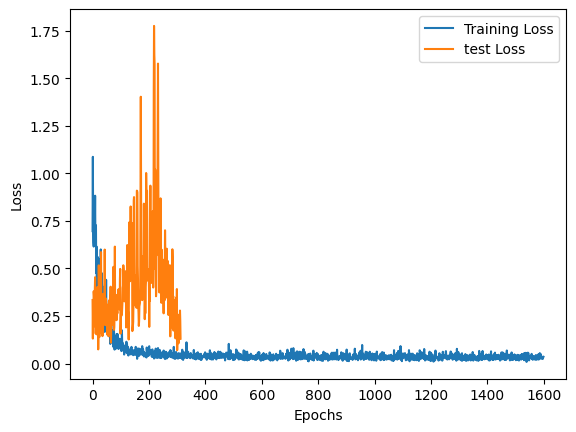

In [183]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Training Loss')
#plt.plot(val_loss, label='Validation Loss')
plt.plot(test_loss, label='test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

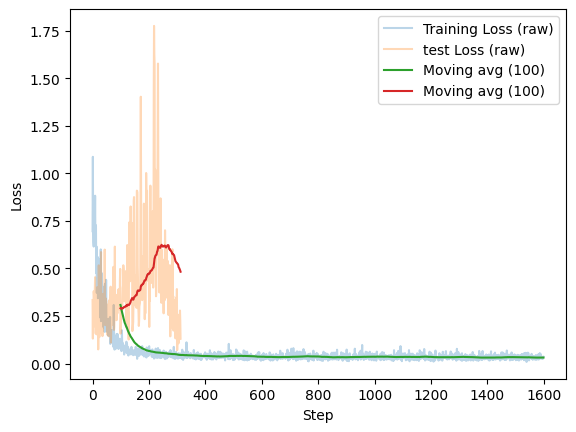

In [185]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
smoothed_train = np.convolve(train_loss, np.ones(window)/window, mode='valid')
#smoothed_val = np.convolve(val_loss, np.ones(window)/window, mode='valid')
smoothed_test = np.convolve(test_loss, np.ones(window)/window, mode='valid')

plt.plot(train_loss, alpha=0.3, label='Training Loss (raw)')
#plt.plot(val_loss, alpha=0.3, label='Validation Loss (raw)')
plt.plot(test_loss, alpha=0.3, label='test Loss (raw)')
plt.plot(range(window-1, len(train_loss)), smoothed_train, label=f'Moving avg ({window})')
#plt.plot(range(window-1, len(val_loss)), smoothed_val, label=f'Moving avg ({window})')
plt.plot(range(window-1, len(test_loss)), smoothed_test, label=f'Moving avg ({window})')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [180]:
def fw(x,h,c,target):
    
    h,logits = model1.con_pred(x,h,c)
    #print(logits.shape,target.shape)
    loss_mse = F.mse_loss(logits, target)
    loss_rmse = torch.sqrt(loss_mse)
    huber_loss = F.huber_loss(logits, target, delta=1.0)
    return loss_mse,loss_rmse,huber_loss

def teacher_forcing(x,h,c,target):
    h,logits = model1(x,h,c)
    #print(logits.shape,target.shape)
    loss = F.mse_loss(logits, target)
    return loss

In [186]:
model1.eval()

# Define the start and end of your test data
test_start = len(new_df) - 5
test_end = len(new_df)

with torch.no_grad():
        X = new_df.iloc[test_start:test_end].values  # (current_b_size, 10, 14)
        pass_df = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
        h_0 = torch.zeros(1, 64) # (current_b_size, hidden_size)
        c_0 = torch.zeros(1, 64) # (current_b_size, hidden_size)
        forecast = model1.forecast(pass_df, h_0, c_0,32) 
        
print(forecast)       


tensor([[[ 1.3610e+00, -1.6924e+00, -1.7838e+00, -2.1964e+00, -3.5623e-01,
          -1.0810e+00, -1.4713e+00, -3.5849e-01, -1.5049e+00, -1.5502e+00,
           1.9894e+00, -4.7448e-03, -2.6342e-02,  3.3578e-01],
         [ 1.3749e+00, -1.6560e+00, -1.7538e+00, -2.2130e+00, -4.9698e-01,
          -1.0919e+00, -1.5109e+00, -4.0657e-01, -1.5439e+00, -1.5618e+00,
           1.9914e+00,  1.0737e-02,  4.8774e-03,  3.0904e-01],
         [ 1.3746e+00, -1.6092e+00, -1.6946e+00, -2.1993e+00, -6.1695e-01,
          -1.1034e+00, -1.5368e+00, -4.3665e-01, -1.5668e+00, -1.5776e+00,
           1.9573e+00,  1.8115e-02,  1.8848e-02,  3.3865e-01],
         [ 1.3701e+00, -1.5629e+00, -1.6380e+00, -2.1653e+00, -6.9703e-01,
          -1.1188e+00, -1.5513e+00, -4.5973e-01, -1.5807e+00, -1.5845e+00,
           1.9144e+00,  2.1145e-02,  2.5873e-02,  3.8861e-01],
         [ 1.3594e+00, -1.5293e+00, -1.5988e+00, -2.1292e+00, -7.3398e-01,
          -1.1362e+00, -1.5598e+00, -4.7977e-01, -1.5885e+00, -1.5852e+00

In [187]:
torch.save(model1.state_dict(), 'base_ml_task2.pth')
